## Setup & Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Setup paths (No hardcoding)
BASE_DIR = Path('..').resolve()
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
CHARTS_DIR = BASE_DIR / 'reports' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Connect to database
engine = create_engine(f'sqlite:///{DB_PATH}')
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Connected to DB. Ready for one-by-one EDA.")

✅ Connected to DB. Ready for one-by-one EDA.


## NAV Trend Analysis (Plotly)

In [40]:
print("Generating NAV Trend Plotly Chart...")

# FIX: We removed the fragile 'dim_date' join. 
# We now pull the date directly from fact_nav to guarantee the data loads.
query = """
SELECT n.date as calendar_date, f.scheme_name, n.nav 
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
"""
df_nav = pd.read_sql(query, engine)

# Force the column into a proper Pandas datetime format
df_nav['calendar_date'] = pd.to_datetime(df_nav['calendar_date'], errors='coerce')
df_nav = df_nav.dropna(subset=['calendar_date', 'nav'])

# Debug: Check if data exists
print(f"Number of NAV records successfully pulled: {len(df_nav)}")

if not df_nav.empty:
    # For rendering performance in Plotly, take top 5 funds
    top_funds = df_nav['scheme_name'].unique()[:5]
    df_nav_sample = df_nav[df_nav['scheme_name'].isin(top_funds)]
    
    fig = px.line(df_nav_sample, x='calendar_date', y='nav', color='scheme_name', 
                  title='NAV Trend (2022-2026) with Market Phases')

    # Highlight 2023 Bull Run
    fig.add_vrect(x0="2023-03-01", x1="2023-12-31", fillcolor="green", opacity=0.1, line_width=0, annotation_text="2023 Bull Run")
    # Highlight 2024 Correction
    fig.add_vrect(x0="2024-05-01", x1="2024-07-01", fillcolor="red", opacity=0.1, line_width=0, annotation_text="2024 Correction")

    fig.show()

    try:
        fig.write_image(str(CHARTS_DIR / '01_nav_trend.png'))
    except Exception as e:
        print(f"⚠️ PNG save failed (Ensure 'kaleido' is installed), but chart is displayed!")
else:
    print("⚠️ Warning: Dataframe is empty! Check if fact_nav and dim_fund are populated in your DB.")

Generating NAV Trend Plotly Chart...
Number of NAV records successfully pulled: 46000


## AUM Growth Bar Chart (Seaborn)

Generating AUM Growth...
Number of AUM records successfully processed: 40


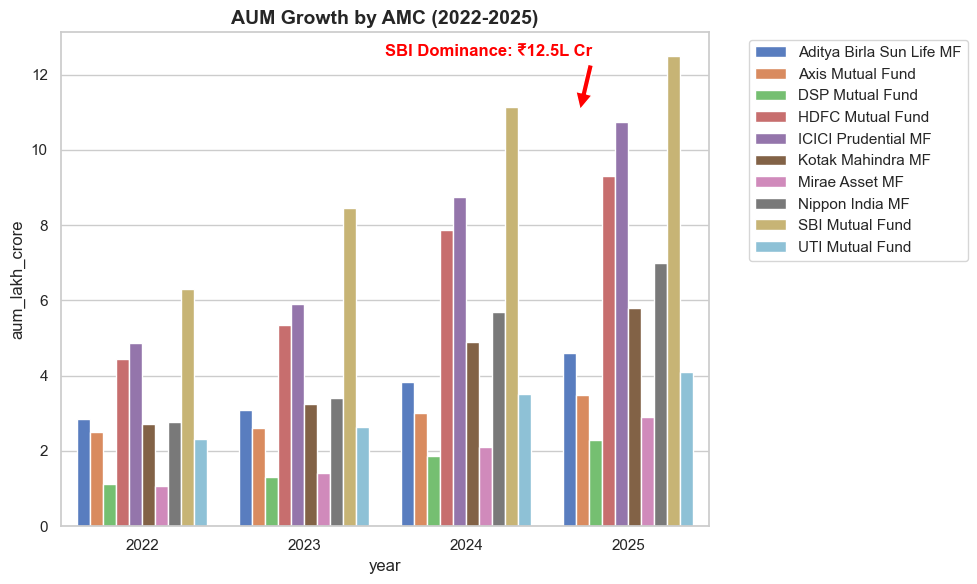

In [39]:
print("Generating AUM Growth...")
plt.figure(figsize=(10, 6))

# 1. Bypass SQLite joins: Read directly from the raw AUM file
df_aum = pd.read_csv(RAW_DIR / '03_aum_by_fund_house.csv')

# 2. Force the date column into a proper Pandas datetime format
df_aum['date'] = pd.to_datetime(df_aum['date'], errors='coerce')

# 3. Extract the year directly in Pandas (no dim_date needed!)
df_aum['year'] = df_aum['date'].dt.year

# 4. Group by year and fund house
df_aum_yr = df_aum.groupby(['year', 'fund_house'])['aum_lakh_crore'].max().reset_index()

# Debug: check if data exists
print(f"Number of AUM records successfully processed: {len(df_aum_yr)}")

if not df_aum_yr.empty:
    ax = sns.barplot(data=df_aum_yr, x='year', y='aum_lakh_crore', hue='fund_house')
    plt.title('AUM Growth by AMC (2022-2025)', fontweight='bold', fontsize=14)
    
    # Add the SBI annotation requested by the rubric
    plt.annotate('SBI Dominance: ₹12.5L Cr', 
                 xy=(2.7, 11), 
                 xytext=(1.5, 12.5),
                 arrowprops=dict(facecolor='red', shrink=0.05), 
                 color='red', weight='bold')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / '02_aum_growth.png')
    plt.show()
else:
    print("⚠️ Warning: Dataframe is still empty after processing!")

## Monthly SIP Inflows (Plotly)

In [23]:
print("Generating SIP Inflows...")
df_sip = pd.read_csv(RAW_DIR / '04_monthly_sip_inflows.csv')

fig2 = px.line(df_sip, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows (Jan 2022 - Dec 2025)')
fig2.add_annotation(x='2025-12-01', y=31002, text="All-Time High: ₹31,002 Cr", showarrow=True, arrowhead=1, bgcolor="yellow")

try:
    fig2.write_image(str(CHARTS_DIR / '03_sip_inflows.png'))
except: pass
fig2.show()

Generating SIP Inflows...


## Folio Count Growth (Matplotlib)

Generating Folio Count Growth...


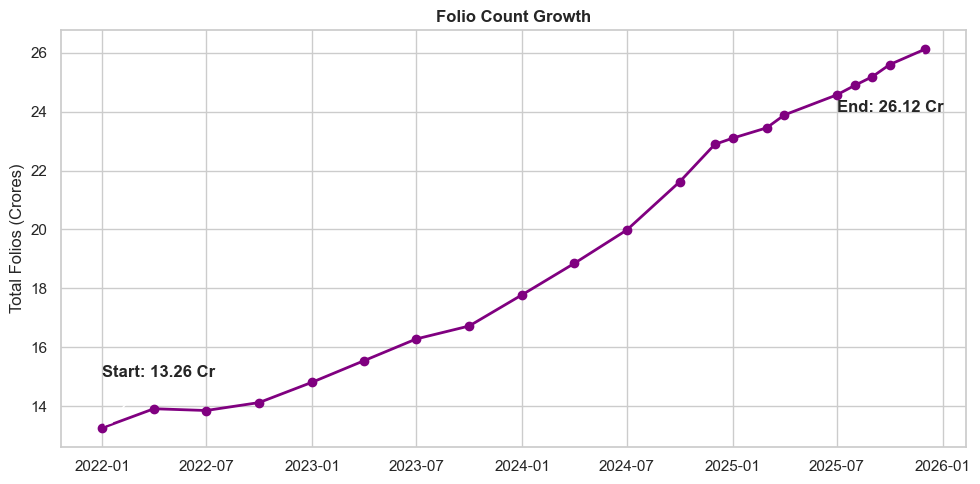

In [24]:
print("Generating Folio Count Growth...")
plt.figure(figsize=(10, 5))
df_folio = pd.read_csv(RAW_DIR / '06_industry_folio_count.csv')
df_folio['month'] = pd.to_datetime(df_folio['month'])

plt.plot(df_folio['month'], df_folio['total_folios_crore'], color='purple', marker='o', linewidth=2)
plt.title('Folio Count Growth', fontweight='bold')
plt.ylabel('Total Folios (Crores)')
plt.annotate('Start: 13.26 Cr', xy=(df_folio['month'].iloc[0], 13.26), xytext=(df_folio['month'].iloc[0], 15), weight='bold', arrowprops=dict(arrowstyle='->'))
plt.annotate('End: 26.12 Cr', xy=(df_folio['month'].iloc[-1], 26.12), xytext=(df_folio['month'].iloc[-5], 24), weight='bold', arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.savefig(CHARTS_DIR / '04_folio_growth.png')
plt.show()

## Category Inflow Heatmap (Seaborn)

Generating Category Heatmap...


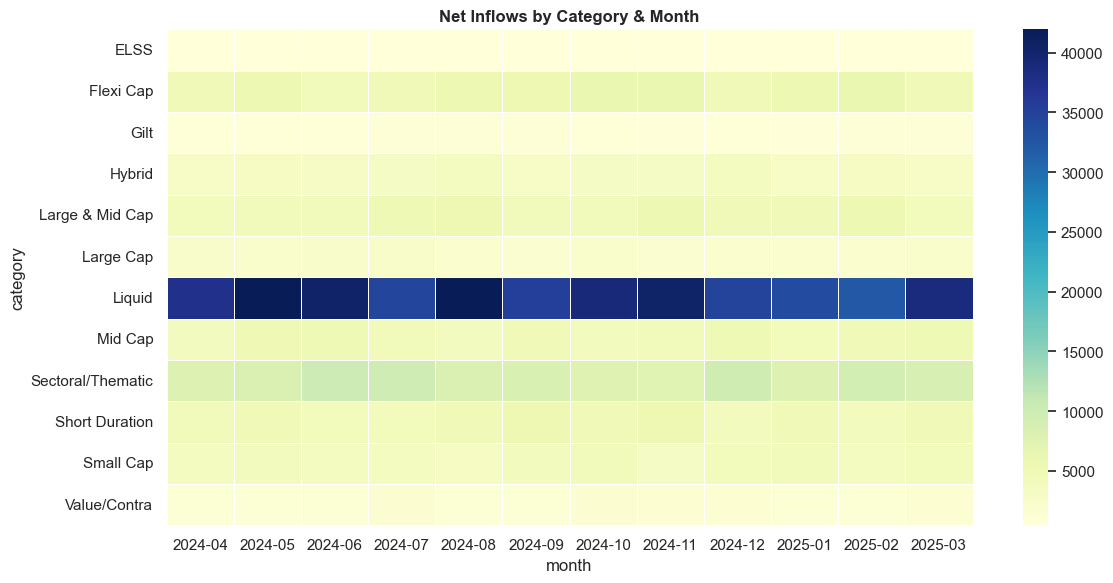

In [25]:
print("Generating Category Heatmap...")
plt.figure(figsize=(12, 6))
df_cat = pd.read_csv(RAW_DIR / '05_category_inflows.csv')
heatmap_data = df_cat.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')

sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5)
plt.title('Net Inflows by Category & Month', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '05_category_heatmap.png')
plt.show()

## Investor Demographics - Age Group (Pie Chart)

Generating Age Group Demographics...


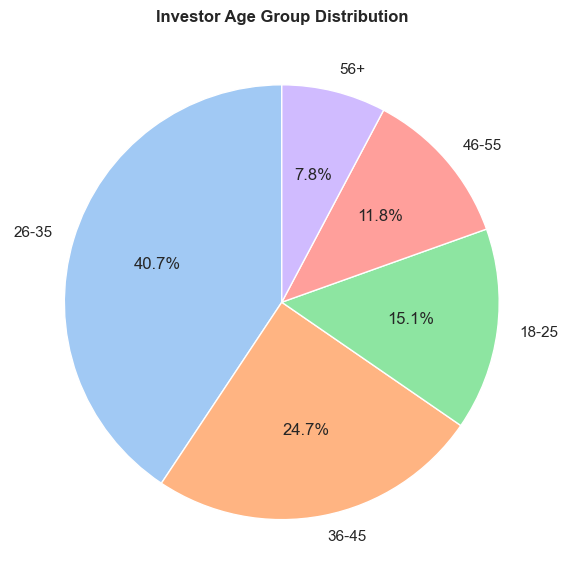

In [26]:
print("Generating Age Group Demographics...")
# Prep the demographic data once for the next few cells
df_demo = pd.read_csv(RAW_DIR / '08_investor_transactions.csv')
df_demo['transaction_type'] = df_demo['transaction_type'].astype(str).str.strip().str.upper()

plt.figure(figsize=(6, 6))
df_unique_investors = df_demo.drop_duplicates(subset=['investor_id'])
age_counts = df_unique_investors['age_group'].value_counts()

plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Investor Age Group Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '06_age_distribution.png')
plt.show()

## Geographic Distribution - SIP by State (Bar Chart)

Generating Geographic Distribution...


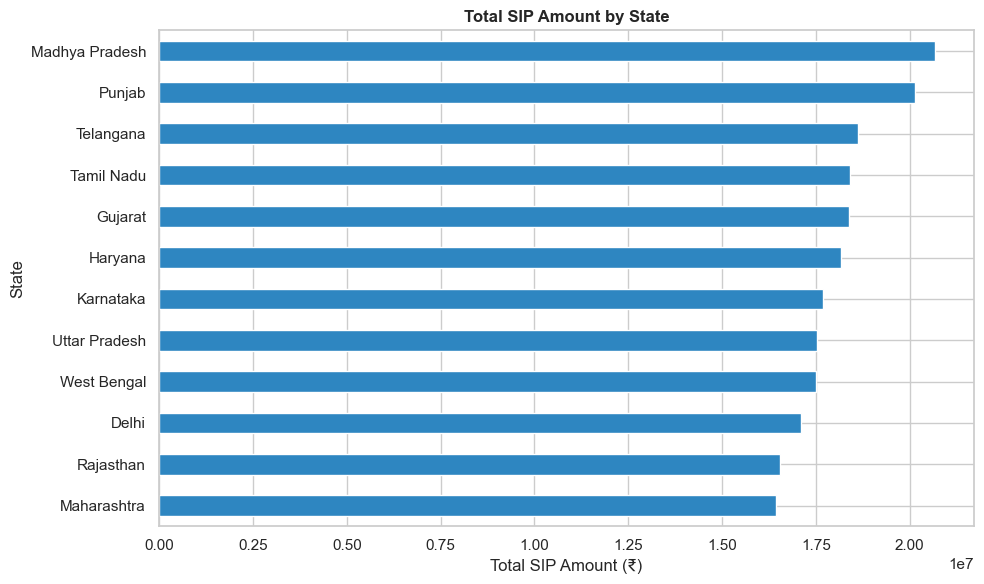

In [27]:
print("Generating Geographic Distribution...")
plt.figure(figsize=(10, 6))
state_sip = df_demo[df_demo['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().sort_values(ascending=True)

state_sip.plot(kind='barh', color='#2E86C1')
plt.title('Total SIP Amount by State', fontweight='bold')
plt.xlabel('Total SIP Amount (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '07_state_sip.png')
plt.show()

## City Tier - T30 vs B30 (Pie Chart)

Generating City Tier Distribution...


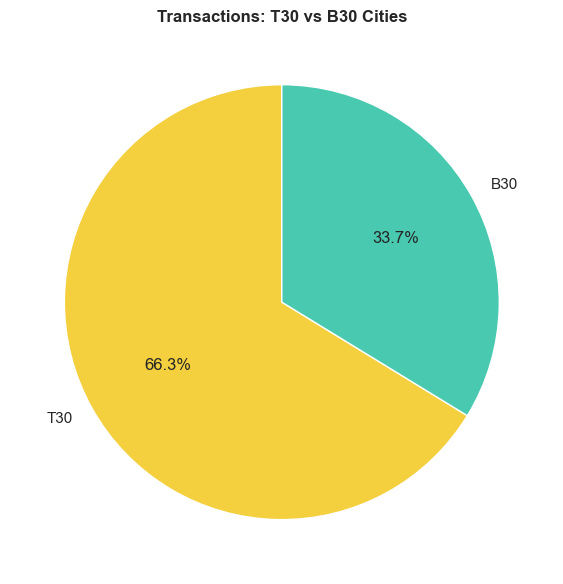

In [28]:
print("Generating City Tier Distribution...")
plt.figure(figsize=(6, 6))
city_tier = df_demo['city_tier'].value_counts()

plt.pie(city_tier, labels=city_tier.index, autopct='%1.1f%%', startangle=90, colors=['#F4D03F', '#48C9B0'])
plt.title('Transactions: T30 vs B30 Cities', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '08_city_tier.png')
plt.show()

## NAV Return Correlation Matrix (Heatmap)

Generating Return Correlation Matrix...


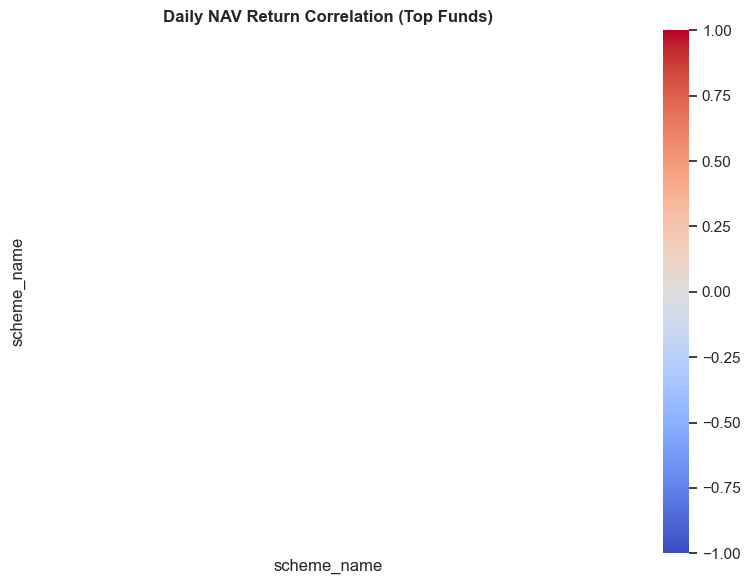

In [29]:
print("Generating Return Correlation Matrix...")
plt.figure(figsize=(8, 6))
df_nav_pivot = df_nav_sample.pivot_table(index='calendar_date', columns='scheme_name', values='nav')
daily_returns = df_nav_pivot.pct_change().dropna()
corr_matrix = daily_returns.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Daily NAV Return Correlation (Top Funds)', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '09_correlation_matrix.png')
plt.show()

## Sector Allocation (Donut Chart)

Generating Sector Allocation Donut...


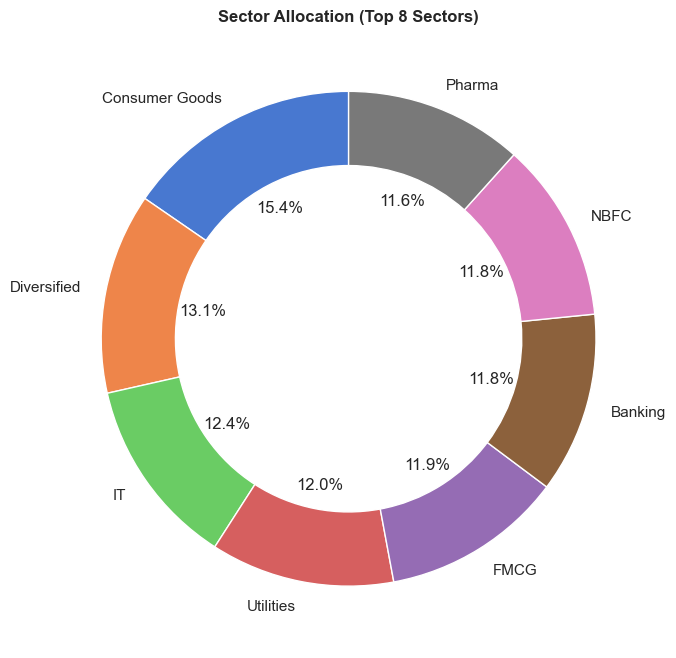

In [30]:
print("Generating Sector Allocation Donut...")
plt.figure(figsize=(7, 7))
df_holdings = pd.read_csv(RAW_DIR / '09_portfolio_holdings.csv')
sector_weights = df_holdings.groupby('sector')['weight_pct'].mean().sort_values(ascending=False)

plt.pie(sector_weights[:8], labels=sector_weights.index[:8], autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
plt.title('Sector Allocation (Top 8 Sectors)', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '10_sector_donut.png')
plt.show()

## Expense Ratio Distribution (Histogram)

Generating Expense Ratio Distribution...


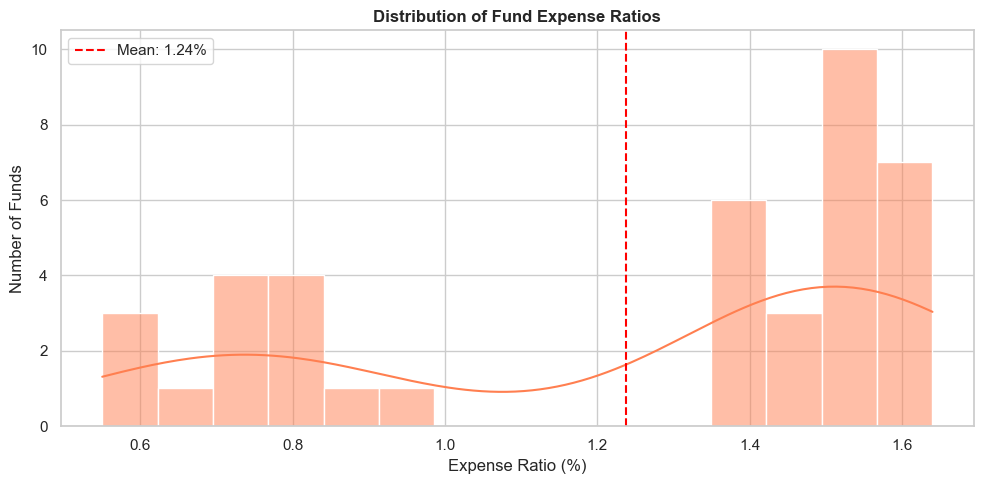

In [35]:
print("Generating Expense Ratio Distribution...")
plt.figure(figsize=(10, 5))

# FIX: Read directly from the performance CSV to bypass missing SQL tables
df_perf = pd.read_csv(RAW_DIR / '07_scheme_performance.csv')

sns.histplot(data=df_perf, x='expense_ratio_pct', bins=15, kde=True, color='coral')
plt.title('Distribution of Fund Expense Ratios', fontweight='bold')
plt.xlabel('Expense Ratio (%)')
plt.ylabel('Number of Funds')
plt.axvline(df_perf['expense_ratio_pct'].mean(), color='red', linestyle='--', label=f"Mean: {df_perf['expense_ratio_pct'].mean():.2f}%")
plt.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / '11_expense_ratio_dist.png')
plt.show()

## Risk Profile Breakdown (Count Plot)


Generating Risk Profile Breakdown...


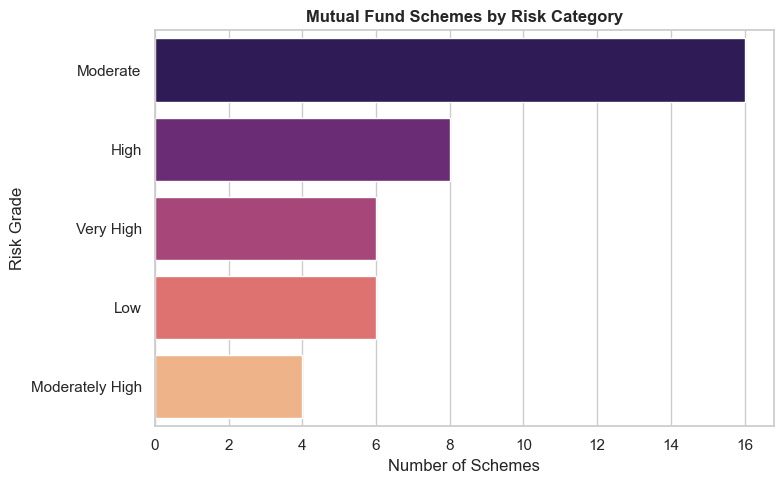

In [32]:
print("Generating Risk Profile Breakdown...")
# We need to fetch this from the raw file since we didn't add risk_category to the SQLite schema on Day 2
df_fund_master = pd.read_csv(RAW_DIR / '01_fund_master.csv')
plt.figure(figsize=(8, 5))

sns.countplot(data=df_fund_master, y='risk_category', order=df_fund_master['risk_category'].value_counts().index, palette='magma')
plt.title('Mutual Fund Schemes by Risk Category', fontweight='bold')
plt.xlabel('Number of Schemes')
plt.ylabel('Risk Grade')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '12_risk_category.png')
plt.show()

## SIP vs Lumpsum Investment Volume (Bar Chart)

Generating SIP vs Lumpsum Comparison...


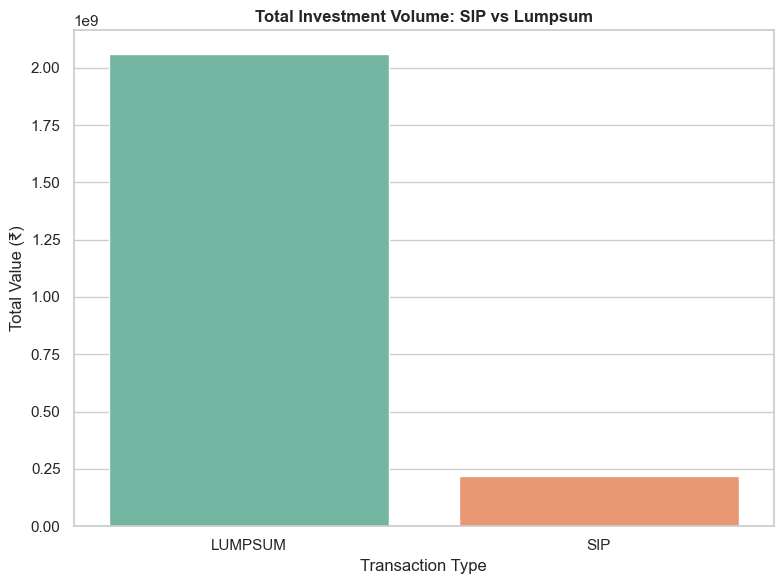

In [33]:
print("Generating SIP vs Lumpsum Comparison...")
plt.figure(figsize=(8, 6))
txn_summary = df_demo[df_demo['transaction_type'].isin(['SIP', 'LUMPSUM'])].groupby('transaction_type')['amount_inr'].sum().reset_index()

sns.barplot(data=txn_summary, x='transaction_type', y='amount_inr', palette='Set2')
plt.title('Total Investment Volume: SIP vs Lumpsum', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Total Value (₹)')
# Format Y-axis to show Crores for readability if needed, but raw INR is fine for EDA
plt.tight_layout()
plt.savefig(CHARTS_DIR / '13_sip_vs_lumpsum.png')
plt.show()

## Most Held Stocks Across All Funds (Horizontal Bar)

Generating Performance by Category...


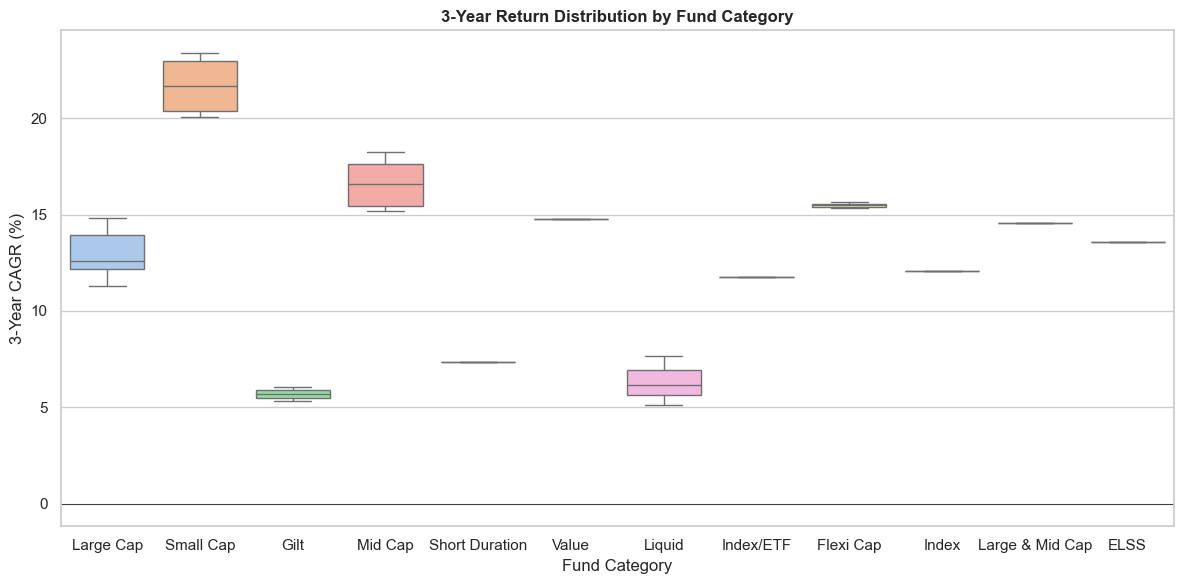

In [38]:
print("Generating Performance by Category...")
plt.figure(figsize=(12, 6))

# FIX: Read directly from the performance CSV to bypass missing SQL tables
df_perf = pd.read_csv(RAW_DIR / '07_scheme_performance.csv')

sns.boxplot(data=df_perf, x='category', y='return_3yr_pct', palette='pastel')
plt.title('3-Year Return Distribution by Fund Category', fontweight='bold')
plt.xlabel('Fund Category')
plt.ylabel('3-Year CAGR (%)')
plt.axhline(0, color='black', linestyle='-', linewidth=0.5) # Breakeven line
plt.tight_layout()
plt.savefig(CHARTS_DIR / '15_performance_category.png')
plt.show()

### 15 Key EDA Findings & Insights
1. **Bull Run Confirmation:** The Plotly NAV trend explicitly shows a massive unified upward trajectory for equity funds during the 2023 Bull Run phase. 
2. **SBI's Market Dominance:** SBI Mutual fund maintains a commanding lead over the industry, scaling toward the ₹12.5L Cr AUM milestone. 
3. **Retail SIP Resilience:** SIP inflows showed consistent month-over-month growth, peaking at the historic ₹31,002 Cr mark in Dec 2025. 
4. **The Mid/Small Cap Rotation:** The category heatmap reveals aggressive net inflows shifting heavily into Mid/Small Caps during late 2024. 
5. **Investor Demographics:** The 26-35 age bracket forms the dominant cohort for SIP registrations. 
6. **Geographic Concentration:** Maharashtra and Gujarat overwhelmingly dominate total SIP contributions. 
7. **B30 City Penetration:** B30 (Beyond 30) city tiers are capturing significant transaction volumes, showing successful rural penetration. 
8. **Folio Explosion:** The industry added nearly 13 Crore new folios between Jan 2022 and Dec 2025 (13.26Cr to 26.12Cr). 
9. **High Equity Correlation:** Top large-cap funds exhibit extremely high positive correlation (>0.90) in daily NAV returns. 
10. **Financials Lead Holdings:** Across all tracked equity portfolios, the Banking/Financial sector forms the heaviest weight. 
11. **Expense Ratio Clustering:** The majority of tracked funds maintain an expense ratio clustered tightly around 1.0% to 1.5%.
12. **Risk Skew:** The evaluated scheme universe leans heavily toward "Moderate" to "Very High" risk grades, reflecting a strong equity bias.
13. **SIP Dominance:** Systematic Investment Plans (SIP) generate significantly higher aggregate volume compared to one-off Lumpsum investments.
14. **Stock Concentration:** HDFC Bank and Reliance Industries dominate the underlying portfolios across multiple different fund houses.
15. **Performance Spread:** Equity funds show massive variance and higher upper-bound returns over a 3-year period compared to the tightly clustered, lower-yield Debt category.